<a href="https://colab.research.google.com/github/LauGabriela/ayda24/blob/Gabriela/ADALINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Implementacion ADALINE
##
### Laura Gabriela Romero Muñiz

In [17]:
import numpy as np

def sigmoid(v): #Sigmoide
  return 1/(1+np.exp(-v))

def dsigmoid(v): # Derivada sigmoide
  return v*(1-v)

def adaline(x, t, eta=0.05, max_it=100000, min_err=0.0001):
    s = 0
    error = 1
    np.random.seed(9001)
    w = np.random.rand(len(t[1,:]), len(x[1,:]))
    b = np.random.rand(1, len(t[1,:]))
    while s < max_it and error > min_err:
        E = 0
        for k in range(0, len(x[:,0])):
            y = sigmoid(np.dot(x[k, :], w.T) + b)
            dy = dsigmoid(y)
            e = t[k,:] - y
            w = w + (e*dy*eta*x[k,:]);
            b = b + (e*dy*eta);
            E = E + e.item()**2 # Replaced np.asscalar with .item()
        error = E / len(x[:,0]);
        s = s + 1
    return w, b

In [18]:
# Define input and target data for the AND gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
T = np.array([[0], [0], [0], [1]])

# Train the ADALINE model
w, b = adaline(X, T)

print("Weights (w):", w)
print("Bias (b):", b)

Weights (w): [[7.27995244 7.27991879]]
Bias (b): [[-11.00737147]]


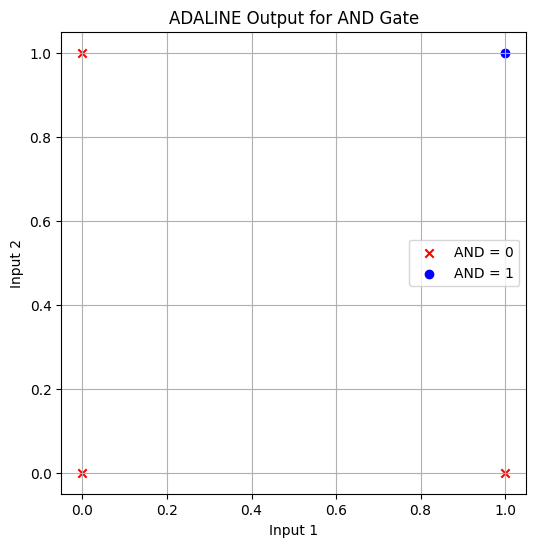

In [20]:
import matplotlib.pyplot as plt

# Calculate the output for each input
output = sigmoid(np.dot(X, w.T) + b)

# Create a scatter plot of the inputs and color-code based on the target output
plt.figure(figsize=(6, 6))
for i in range(len(X)):
    if T[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], color='blue', marker='o', label='AND = 1' if i == 3 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], color='red', marker='x', label='AND = 0' if i == 0 else "")

# Plot the decision boundary (optional, as ADALINE doesn't have a strict boundary like perceptron)
# However, we can visualize a line that separates the outputs based on a threshold (e.g., 0.5)
# This requires finding two points on the boundary line w1*x1 + w2*x2 + b = 0.5
# For simplicity, we can plot a line that visually separates the points.
# A more accurate boundary requires solving for the line where sigmoid(w*x + b) = 0.5

# Adding labels and title
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("ADALINE Output for AND Gate")
plt.grid(True)
plt.legend()
plt.show()